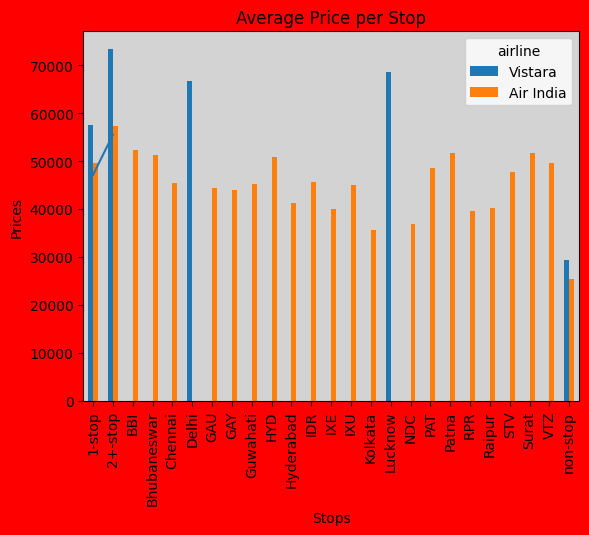

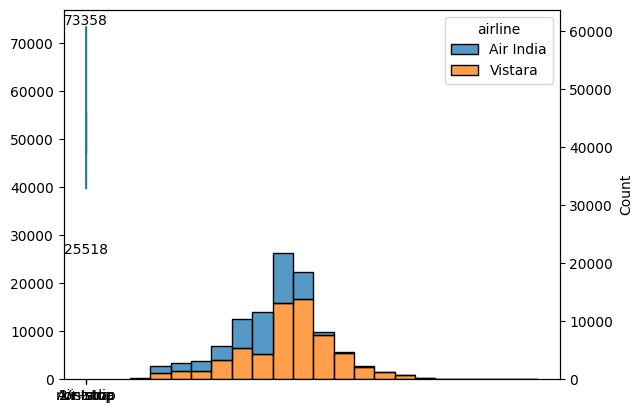

<Axes: xlabel='time_taken_mins', ylabel='price'>

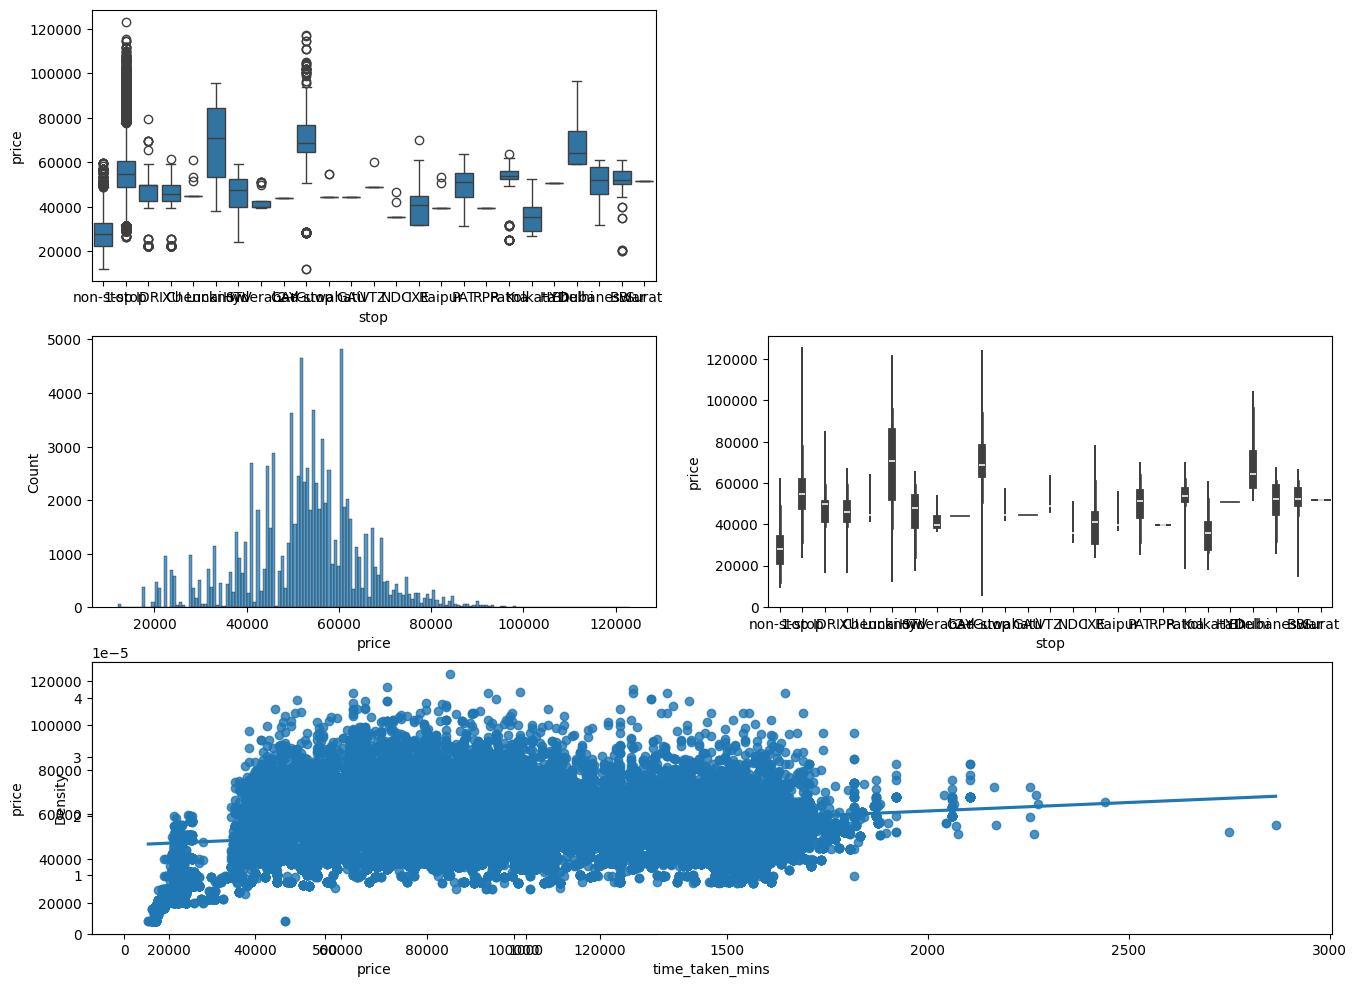

In [3]:
#importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

business_df=pd.read_csv('business.csv')

# Q1. How do you clean the price column that has commas in it (like '1,23,456')?
business_df['price'] = business_df['price'].str.replace(',', '').astype(int)
# Business class prices range roughly from ₹3,500 to ₹1,23,000 — a huge spread,
# suggesting route length and airline brand play a big role in pricing.

# Q2. How do you clean the stop column that has messy whitespace and extra words like '1-stop Via'?
business_df['stop'] = business_df['stop'].str.split().str.join('')
business_df['stop'] = business_df['stop'].str.replace('1-stopVia', '')
# After cleaning, stops reduce to two clean categories: zero and one.
# Most business class flights are non-stop, which already hints at a convenience premium.

# Q3. How do you plot average price per airline as a line plot with labels and title?
averageAirlinePrice = business_df.groupby('airline')['price'].mean()
fig, ax = plt.subplots()
ax.plot(averageAirlinePrice.index, averageAirlinePrice.values)
ax.set_xlabel('Airlines')
ax.set_ylabel('Average Price')
ax.set_title('Average Price of Airlines')
# Vistara sits noticeably higher than Air India in average price.
# Only two airlines operate business class on domestic Indian routes in this dataset,
# which makes the comparison clean and direct.

# Q4. How do you set the background color of the plot area and the figure?
ax.set_facecolor("lightgray")
fig.set_facecolor('red')
# Purely aesthetic — no analytical insight here, but useful to know for
# matching a portfolio or presentation color scheme.

# Q5. How do you plot a grouped bar chart for Vistara and Air India comparing price per stop?
avgAirlinePriceAll = business_df.groupby(['airline','stop'])['price'].mean().unstack()
avgAirlinePriceAll.loc[['Vistara', 'Air India']].T.plot(kind='bar', ax=ax)
ax.set_xlabel('Stops')
ax.set_ylabel('Prices')
ax.set_title('Average Price per Stop')
# Vistara charges more than Air India for both zero-stop and one-stop flights.
# Interestingly, non-stop flights cost more than one-stop for both airlines —
# passengers pay a premium for direct routing even in business class.

# Q6. How do you plot average price and flight count on the same chart with two different y-axes?
flight_count = business_df.groupby('airline').size()
averageAirlinePrice = business_df.groupby('airline')['price'].mean()
fig, ax = plt.subplots()
ax.plot(averageAirlinePrice.index, averageAirlinePrice.values)
ax2 = ax.twinx()
ax2.plot(flight_count.index, flight_count.values)
# Air India operates more flights but at lower prices.
# Vistara operates fewer flights and charges more — a classic premium positioning strategy.

# Q7. How do you save a figure as a high-quality PNG for a README or portfolio?
plt.savefig('myheheplot.png', dpi=300, bbox_inches='tight')
# dpi=300 is the threshold for print-quality images.
# bbox_inches='tight' prevents rotated tick labels from getting clipped at the edges.

# Q8. How do you find and annotate the cheapest and most expensive airline on a bar chart?
lowestprice = avgAirlinePriceAll.min().min()
lowestpriceName = avgAirlinePriceAll.min().idxmin()
highestprice = avgAirlinePriceAll.max().max()
highestpriceName = avgAirlinePriceAll.max().idxmax()
ax.bar([lowestpriceName, highestpriceName], [lowestprice, highestprice])
ax.text(0, lowestprice, f'{lowestprice:.0f}', ha='center', va='bottom')
ax.text(1, highestprice, f'{highestprice:.0f}', ha='center', va='bottom')
# The price gap between the cheapest and most expensive airline is significant.
# Annotating exact values makes the chart self-contained — a reader doesn't need
# to look at the axis to understand the magnitude of the difference.

# Q9. How do you compare price distributions across all airlines in one stacked histogram?
sns.histplot(data=business_df, x='price', hue='airline', multiple='stack', bins=20)
plt.show()
# Both airlines show a right-skewed distribution — most flights cluster at lower
# price ranges, with a long tail of expensive outliers (likely long-haul routes).
# Vistara's stack sits higher in the upper price bins, confirming its premium pricing.

# Q10. How do you convert a duration string like '2h 35m' into total minutes as a numeric column?
business_df['time_taken_mins'] = (
    business_df['time_taken']
    .str.extract(r'(\d+)h\s+(\d+)m')
    .astype(int)
    .pipe(lambda x: x[0]*60 + x[1])
)
# Converting to minutes makes duration a proper numeric feature.
# Domestic business flights in this dataset range from roughly 75 mins to 3+ hours,
# reflecting the spread between short hops (Delhi-Mumbai) and longer routes.

# Q11. How do you build a full seaborn dashboard using matplotlib GridSpec?
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])
sns.boxplot(data=business_df, x='stop', y='price', ax=ax1)
# Boxplot: non-stop flights have a higher median price and more outliers than one-stop.
sns.histplot(data=business_df, x='price', ax=ax2)
# Histogram: confirms right skew — most fares cluster below ₹30,000.
sns.kdeplot(data=business_df, x='price', ax=ax3)
# KDE: smoother view of the same skew — the long tail towards ₹1L+ is clearly visible.
sns.violinplot(data=business_df, x='stop', y='price', ax=ax4)
# Violin: non-stop flights have a fatter upper body, meaning more price variation.
sns.regplot(data=business_df, x='time_taken_mins', y='price', ax=ax5)
# Regplot: positive trend — longer flights cost more. The confidence band widens
# at higher durations, meaning fewer long routes and more price variability there.

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'time_taken_mins'],
      dtype='object')